# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-23 22:39:11.707436: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 22:39:11.710270: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 22:39:11.740222: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 22:39:11.740265: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 22:39:11.740329: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Python executable: /home/chetanm/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32) - 1
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"), dtype=np.float32)
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"), dtype=np.int32) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection

In [4]:
label_counts = pd.Series(y_train).value_counts().sort_index()
summary_df = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})
summary_df


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 5ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 3ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 2s 21ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 1s 7ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 1s 6ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 3ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [=

### Training Curves

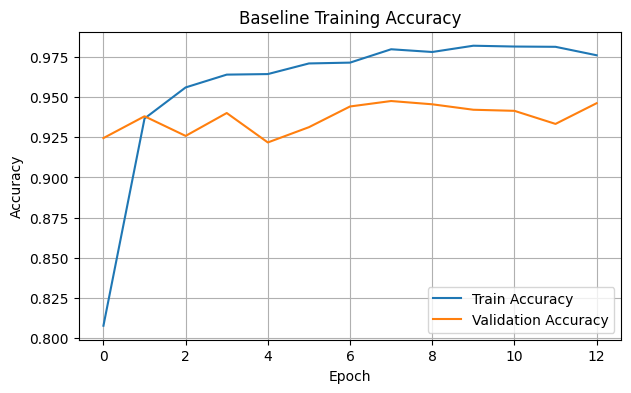

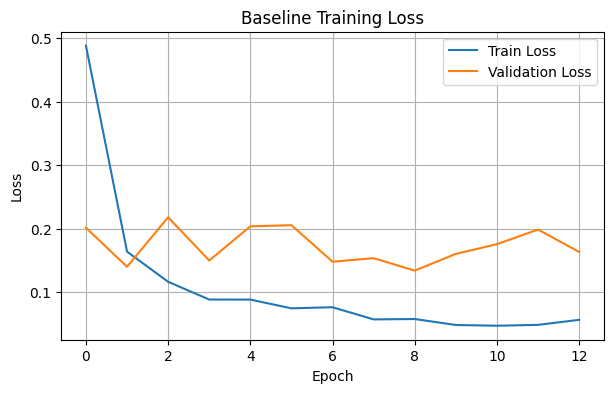

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training Loss")
plt.legend()
plt.grid(True)
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 1ms/step
Baseline Keras Test Accuracy: 0.9220
                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



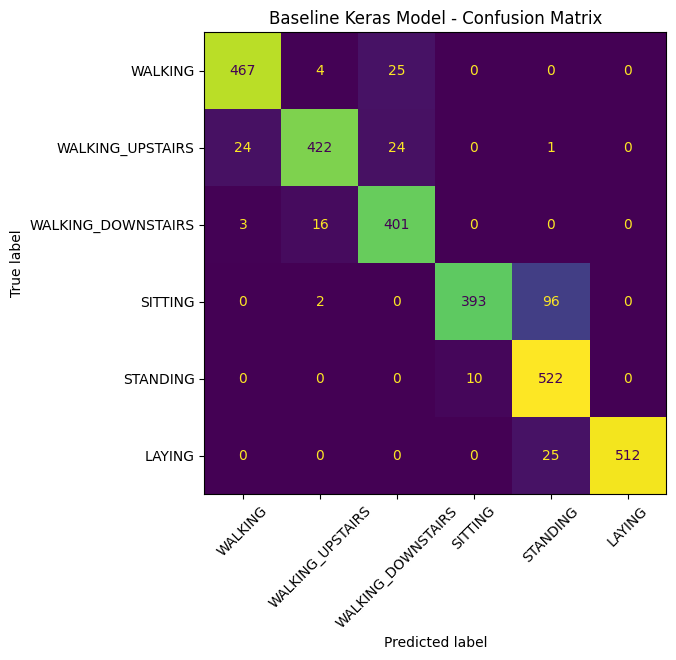

In [8]:
baseline_probs = baseline_model.predict(X_test)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc = accuracy_score(y_test, baseline_preds)

print(f"Baseline Keras Test Accuracy: {baseline_acc:.4f}")
print(classification_report(y_test, baseline_preds, target_names=class_names))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Baseline Keras Model - Confusion Matrix")
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point)
            x = np.clip(x, -128, 127).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point)
            x = np.clip(x, 0, 255).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_fp32_acc, baseline_fp32_preds = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite Accuracy: {baseline_fp32_acc:.4f}")
print(f"Baseline FP32 TFLite Size: {baseline_fp32_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpfkt3atew/assets


INFO:tensorflow:Assets written to: /tmp/tmpfkt3atew/assets
2026-04-23 22:39:23.438046: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:39:23.438090: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:39:23.438328: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfkt3atew
2026-04-23 22:39:23.438854: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:39:23.438862: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfkt3atew
2026-04-23 22:39:23.441551: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-04-23 22:39:23.442014: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:39:23.470883: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

Baseline FP32 TFLite Accuracy: 0.9220
Baseline FP32 TFLite Size: 726.72 KB


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [11]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)
pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

fresh_model = build_baseline_model(num_features, num_classes)
pruned_model = prune_low_magnitude(fresh_model, **pruning_params)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

pruning_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)


Epoch 1/12
92/92 [==============================] - 2s 5ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 3ms/step - loss: 0.1662 - accuracy: 0.9373 - val_loss: 0.1596 - val_accuracy: 0.9286
Epoch 3/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1310 - accuracy: 0.9493 - val_loss: 0.2198 - val_accuracy: 0.9279
Epoch 4/12
92/92 [==============================] - 0s 5ms/step - loss: 0.0920 - accuracy: 0.9691 - val_loss: 0.1562 - val_accuracy: 0.9354
Epoch 5/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1559 - accuracy: 0.9429 - val_loss: 0.1403 - val_accuracy: 0.9395
Epoch 6/12
92/92 [==============================] - 1s 6ms/step - loss: 0.1319 - accuracy: 0.9565 - val_loss: 0.1508 - val_accuracy: 0.9334
Epoch 7/12
92/92 [==============================] - 1s 6ms/step - loss: 0.3422 - accuracy: 0.9221 - val_loss: 0.1753 - val_accuracy: 0.9313
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [12]:
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

stripped_pruned_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned with Mask Accuracy: {pruned_with_mask_acc:.4f}, Size: {pruned_with_mask_size_kb:.2f} KB")
print(f"Stripped Sparse Accuracy: {stripped_sparse_acc:.4f}, Size: {stripped_sparse_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmp1qb6ocfu/assets


INFO:tensorflow:Assets written to: /tmp/tmp1qb6ocfu/assets
2026-04-23 22:39:29.917541: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:39:29.917582: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:39:29.917680: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1qb6ocfu
2026-04-23 22:39:29.920355: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:39:29.920369: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1qb6ocfu
2026-04-23 22:39:29.928453: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:39:29.966725: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1qb6ocfu
2026-04-23 22:39:29.978698: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp0pivcjwk/assets


INFO:tensorflow:Assets written to: /tmp/tmp0pivcjwk/assets


Pruned with Mask Accuracy: 0.9230, Size: 1454.18 KB
Stripped Sparse Accuracy: 0.9230, Size: 338.85 KB


2026-04-23 22:39:30.651290: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:39:30.651334: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:39:30.651425: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0pivcjwk
2026-04-23 22:39:30.651798: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:39:30.651805: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp0pivcjwk
2026-04-23 22:39:30.652587: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:39:30.662401: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp0pivcjwk
2026-04-23 22:39:30.666106: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 14680 m

## 11. Part I Comparison: Accuracy and Model Size

In [13]:
part1_results = pd.DataFrame([
    ["Baseline", "FP32 TFLite", baseline_fp32_acc, baseline_fp32_size_kb],
    ["Pruned with Mask", "FP32 TFLite", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse", "FP32 + Sparse TFLite", stripped_sparse_acc, stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])
part1_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.921955,726.718750
1,Pruned with Mask,FP32 TFLite,0.922973,1454.175781
2,Stripped Sparse,FP32 + Sparse TFLite,0.922973,338.851562


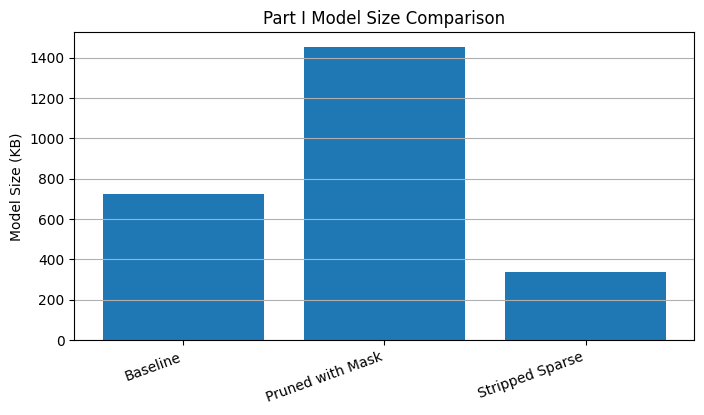

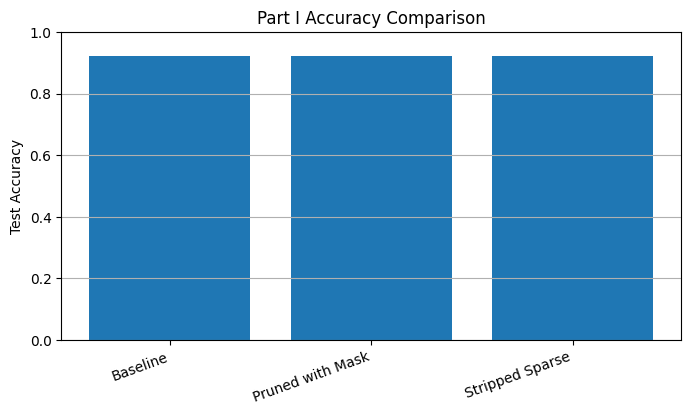

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(part1_results["Model"], part1_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Part I Model Size Comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(part1_results["Model"], part1_results["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Part I Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.0)
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Stripped Sparse Model

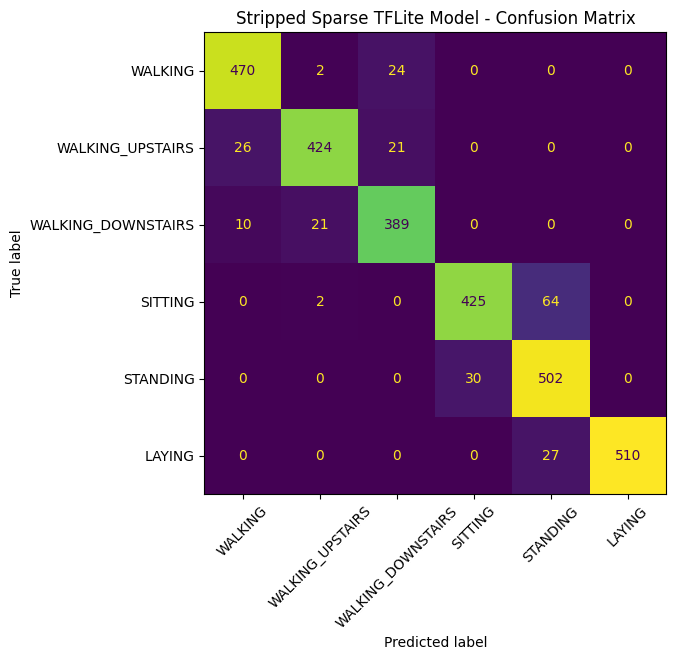

                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.90      0.93      0.91       420
           SITTING       0.93      0.87      0.90       491
          STANDING       0.85      0.94      0.89       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [15]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Stripped Sparse TFLite Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_preds, target_names=class_names))


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_float16_tflite = converter.convert()

pruned_float16_size_kb = save_binary_model(pruned_float16_tflite, "pruned_with_mask_float16.tflite")
pruned_float16_acc, pruned_float16_preds = evaluate_tflite_model(pruned_float16_tflite, X_test, y_test)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = converter.convert()

stripped_sparse_float16_size_kb = save_binary_model(stripped_sparse_float16_tflite, "stripped_sparse_float16.tflite")
stripped_sparse_float16_acc, stripped_sparse_float16_preds = evaluate_tflite_model(stripped_sparse_float16_tflite, X_test, y_test)

print(f"Pruned Float16 Accuracy: {pruned_float16_acc:.4f}, Size: {pruned_float16_size_kb:.2f} KB")
print(f"Stripped Sparse Float16 Accuracy: {stripped_sparse_float16_acc:.4f}, Size: {stripped_sparse_float16_size_kb:.2f} KB")


INFO:tensorflow:Assets written to: /tmp/tmpf_teviot/assets


INFO:tensorflow:Assets written to: /tmp/tmpf_teviot/assets
2026-04-23 22:39:32.307021: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:39:32.307063: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:39:32.307164: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpf_teviot
2026-04-23 22:39:32.308496: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:39:32.308505: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpf_teviot
2026-04-23 22:39:32.313684: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:39:32.346566: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpf_teviot
2026-04-23 22:39:32.358230: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp8sl1pwpx/assets


INFO:tensorflow:Assets written to: /tmp/tmp8sl1pwpx/assets
2026-04-23 22:39:33.025716: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-23 22:39:33.025757: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-23 22:39:33.025858: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp8sl1pwpx
2026-04-23 22:39:33.026208: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-23 22:39:33.026218: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp8sl1pwpx
2026-04-23 22:39:33.027037: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-23 22:39:33.037574: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp8sl1pwpx
2026-04-23 22:39:33.041261: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Pruned Float16 Accuracy: 0.9230, Size: 732.59 KB
Stripped Sparse Float16 Accuracy: 0.9230, Size: 223.71 KB


## 12. Part II Comparison: Accuracy and Model Size

In [17]:
part2_results = pd.DataFrame([
    ["Pruned with Mask", "FP32", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Pruned with Mask", "Float16", pruned_float16_acc, pruned_float16_size_kb],
    ["Stripped Sparse", "Sparse + Float16", stripped_sparse_float16_acc, stripped_sparse_float16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])
part2_results


,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned with Mask,FP32,0.922973,1454.175781
1,Stripped Sparse,FP32 + Sparse,0.922973,338.851562
2,Pruned with Mask,Float16,0.922973,732.585938
3,Stripped Sparse,Sparse + Float16,0.922973,223.710938


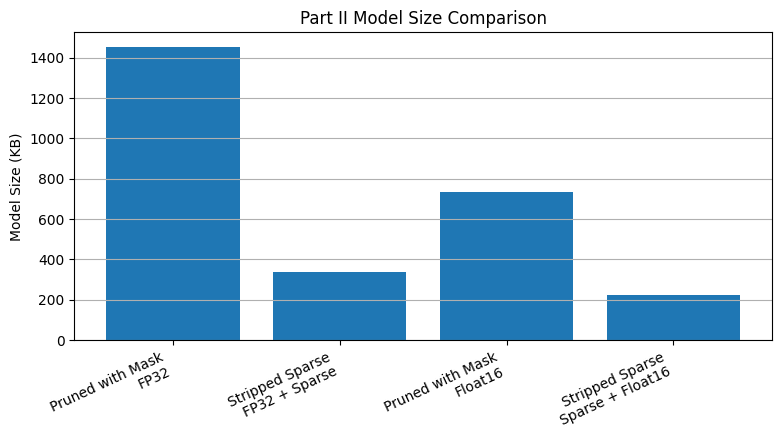

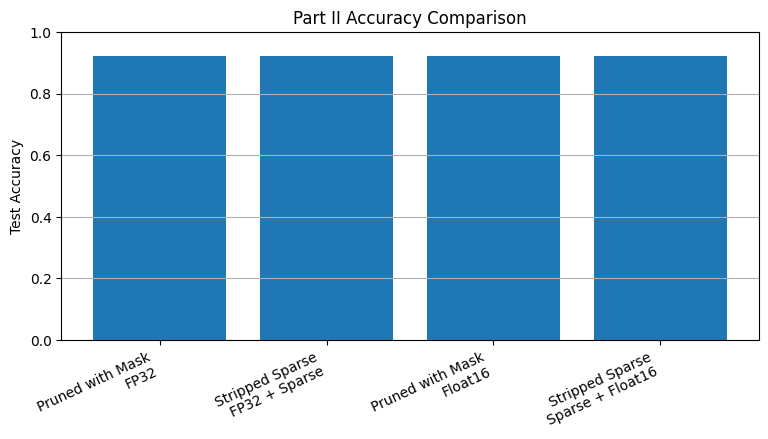

In [18]:
labels = part2_results["Model"] + "\n" + part2_results["Format"]

plt.figure(figsize=(9, 4))
plt.bar(labels, part2_results["Model Size (KB)"])
plt.ylabel("Model Size (KB)")
plt.title("Part II Model Size Comparison")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(labels, part2_results["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Part II Accuracy Comparison")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.0)
plt.grid(axis="y")
plt.show()


### Confusion Matrix for the Stripped Sparse + Float16 Model

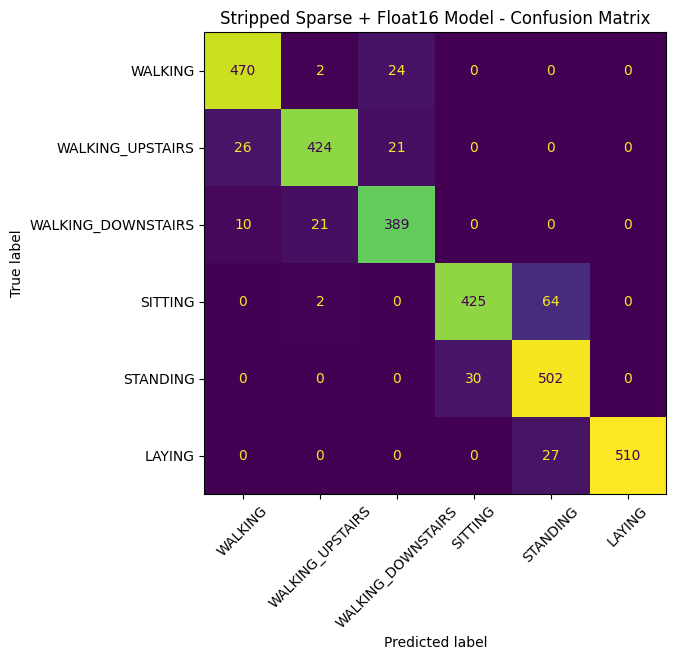

                    precision    recall  f1-score   support

           WALKING       0.93      0.95      0.94       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.90      0.93      0.91       420
           SITTING       0.93      0.87      0.90       491
          STANDING       0.85      0.94      0.89       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_float16_preds),
    display_labels=class_names,
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Stripped Sparse + Float16 Model - Confusion Matrix")
plt.show()

print(classification_report(y_test, stripped_sparse_float16_preds, target_names=class_names))


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached? No
2. Why does `strip_pruning(...)` matter before export? It leaves only the final sparse weights.
3. Which model had the smallest file size in this notebook? Stripped sParse + float16
4. Did float16 quantization noticeably change the test accuracy? No impact on test accuracy
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
   I would chose the stripped sprase as accuracy is similar but with smaller size


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
